# Crime as it Relates to Income in Tucson: 
# Examining Data-Driven Insights by Ward

### Authors:
* Jon Thrall
* Ming Wang
* Jaidon McIntosh-Cassa

## Imports
These are all of the necessary imports to properly run this file.

In [21]:
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model as lm
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns
import pandas as pd
import numpy as np

In [22]:
"""
Read in all CSV objects for later use
"""

arrests_df = pd.read_csv("arrests.csv")
crimes_train = pd.read_csv("crimes.csv")
income_train = pd.read_csv("income.csv")

/var/folders/4s/ftq61v4n7vs1z56p0j9bk04c0000gn/T/ipykernel_39009/1999024420.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  arrests_df = pd.read_csv("arrests.csv")
/var/folders/4s/ftq61v4n7vs1z56p0j9bk04c0000gn/T/ipykernel_39009/1999024420.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  crimes_train = pd.read_csv("crimes.csv")


# Data Processing and Visualizations (#1)
This script processes Tucson Police Reported Crimes data and performs the following tasks:

1. **Data Loading and Cleaning**  
   - Loads the dataset containing reported crime data.  
   - Shuffles the dataset and resets the index for randomized ordering.  
   - Handles missing or invalid data in the 'Ward' column by replacing `NaN` values with 0 and converting all values to integers.  
   - Removes rows where the 'Ward' value is 0 to focus on valid entries.  
   - Cleans the 'TimeOccur' column by converting it to string format and stripping unnecessary spaces.  

2. **Feature Extraction**  
   - Extracts the hour of the day from the 'TimeOccur' column (e.g., converts "1435" to "14").  
   - Handles invalid or missing time values by dropping rows with `NaN` in the derived 'Hour' column.  
   - Converts the extracted 'Hour' values to integers for further analysis.  

3. **Data Aggregation**  
   - Groups the data by 'Ward' and 'Hour' to calculate the number of crimes committed in each hour for each ward.  
   - Computes the total number of crimes for each ward.  

4. **Visualization**  
   - Creates bar plots for each ward to visualize the distribution of crimes by hour of the day.  
   - Adds the total number of crimes for each ward as annotations on the plots.  
   - Customizes the x-axis to display all hours (0–23) for clear interpretation.  
   - Adjusts the layout to ensure readability of the plots.  

The visualizations provide a detailed overview of hourly crime patterns across different wards, helping identify trends and potential areas of focus for resource allocation and crime prevention.


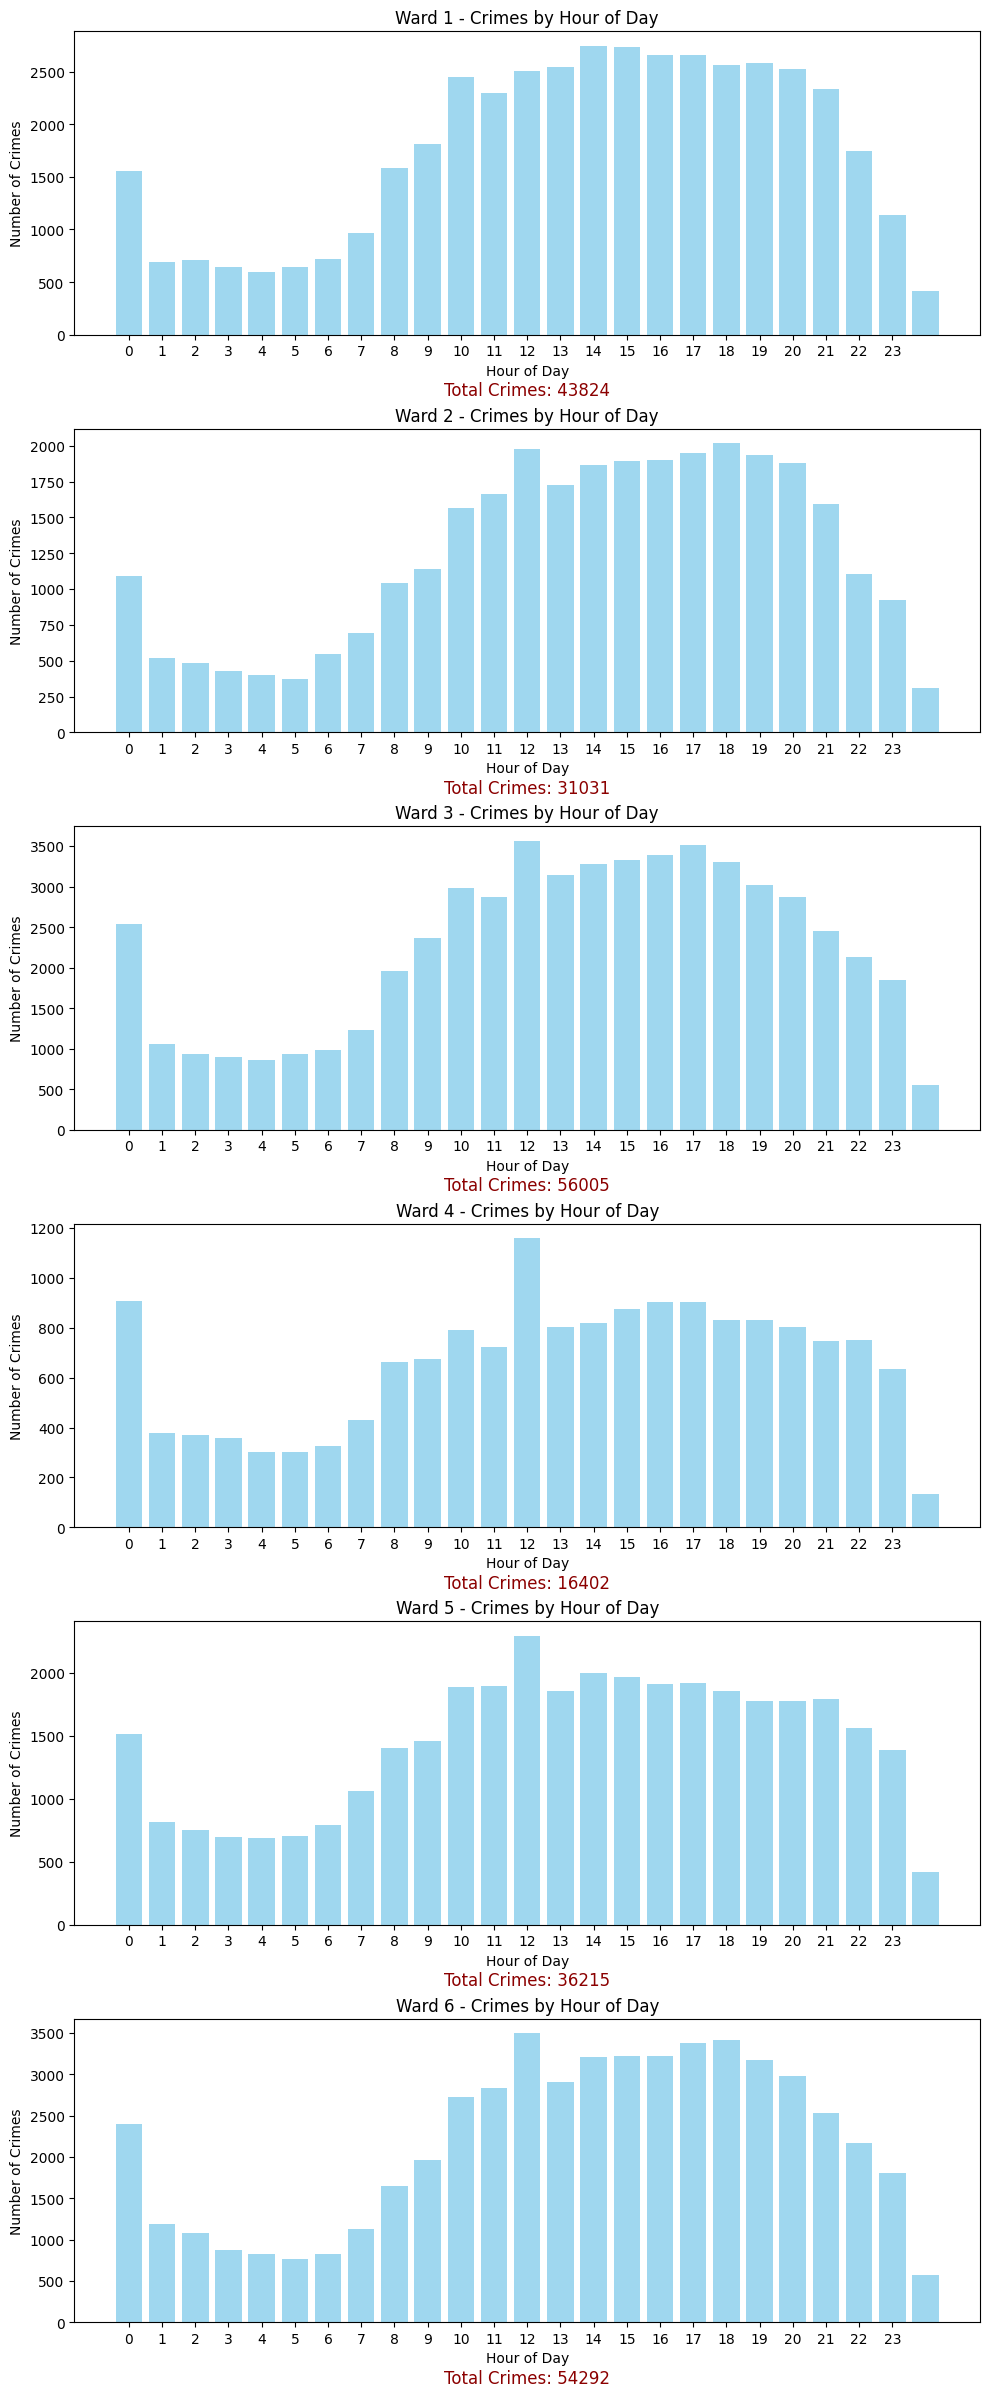

In [23]:
crimes_train = crimes_train.sample(frac=1).reset_index(drop=True)
crimes_train['Ward'] = crimes_train['Ward'].fillna(0).astype(int)

# Remove rows where 'Ward' is 0
crimes_train = crimes_train[crimes_train['Ward'] != 0]

# Clean the TimeOccur column
crimes_train['TimeOccur'] = crimes_train['TimeOccur'].astype(str).str.strip()

# Extract hours by dividing the time string (e.g., "1435" -> "14")
crimes_train['Hour'] = pd.to_numeric(crimes_train['TimeOccur'].str[:2], errors='coerce')

# Drop rows where Hour is NaN (invalid/missing times)
crimes_train = crimes_train.dropna(subset=['Hour']).copy()

# Convert Hour to integer
crimes_train['Hour'] = crimes_train['Hour'].astype(int)

# Group by Ward and Hour to count the number of crimes
hourly_crime_counts = crimes_train.groupby(['Ward', 'Hour']).size().reset_index(name='CrimeCount')

# Calculate the total number of crimes per ward
total_crime_per_ward = crimes_train['Ward'].value_counts().sort_index()

# Generate graphs
wards = hourly_crime_counts['Ward'].unique()
num_wards = len(wards)
fig, axes = plt.subplots(num_wards, 1, figsize=(10, num_wards * 4))

for i, ward in enumerate(wards):
    ward_data = hourly_crime_counts[hourly_crime_counts['Ward'] == ward]
    axes[i].bar(ward_data['Hour'], ward_data['CrimeCount'], color='skyblue', alpha=0.8)
    axes[i].set_title(f'Ward {ward} - Crimes by Hour of Day')
    axes[i].set_ylabel('Number of Crimes')

    # Add the total crime count for this ward at the bottom
    total_crime = total_crime_per_ward.get(ward, 0)
    axes[i].text(0.5, -0.2, f'Total Crimes: {total_crime}', transform=axes[i].transAxes,
                 ha='center', fontsize=12, color='darkred')

    # Set x-label for all subplots
    axes[i].set_xlabel('Hour of Day')

    # Adjust x-ticks to show every hour
    axes[i].set_xticks(range(0, 24, 1))  # Show every hour on the x-axis

# Adjust layout for readability
plt.tight_layout()
plt.show()


# Data Processing and Visualizations (#2)
This script processes Tucson Neighborhood Income data and performs the following tasks:

1. **Data Loading and Cleaning**  
   - Loads the dataset containing neighborhood income information.  
   - Retains relevant columns such as 'Ward', 'Neighborhood', 'TotalHouseholds', and 'WealthIndex'.  
   - Renames columns for consistency with other datasets.  
   - Handles missing values by replacing them with suitable defaults (e.g., 0 for TotalHouseholds, median for WealthIndex).  

2. **Data Organization**  
   - Sorts the dataset by 'Ward' in ascending order to ensure proper numerical order.  
   - Aggregates data to compute the total number of households for each ward.  

3. **Visualization**  
   - Generates a bar plot displaying the total number of households per ward.  
   - Creates scatterplots for each ward, comparing Wealth Index against Total Households.  
   - Provides customizations like grid lines, labeled axes, and specific ranges for x-axis based on data distribution.  

The visualizations aim to provide insights into the distribution of household wealth and size across different wards, facilitating data-driven decision-making and analysis.


/var/folders/4s/ftq61v4n7vs1z56p0j9bk04c0000gn/T/ipykernel_39009/3150475732.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ward', y='TotalHouseholds', data=household_counts, palette='Blues_d')


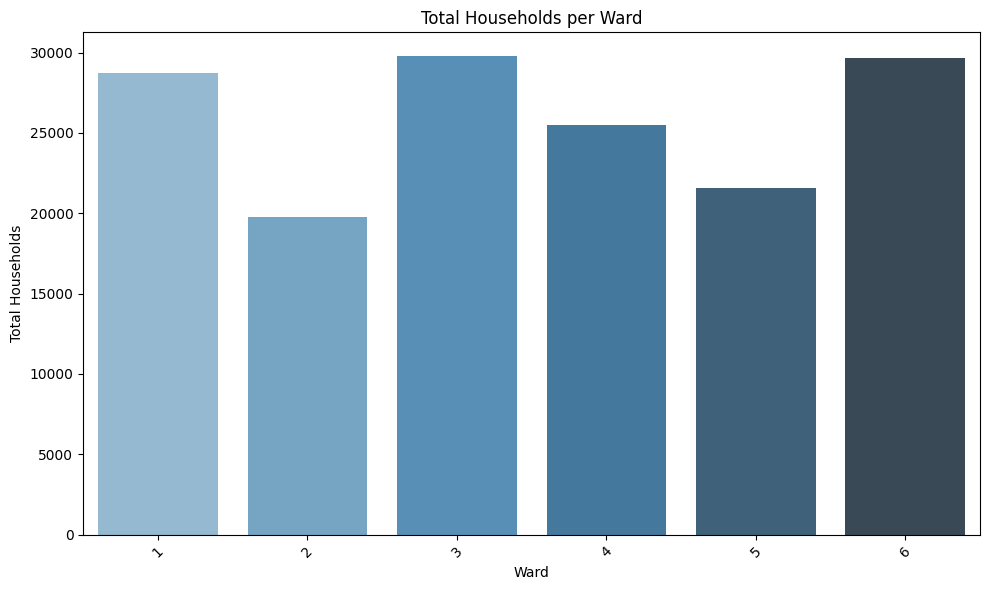

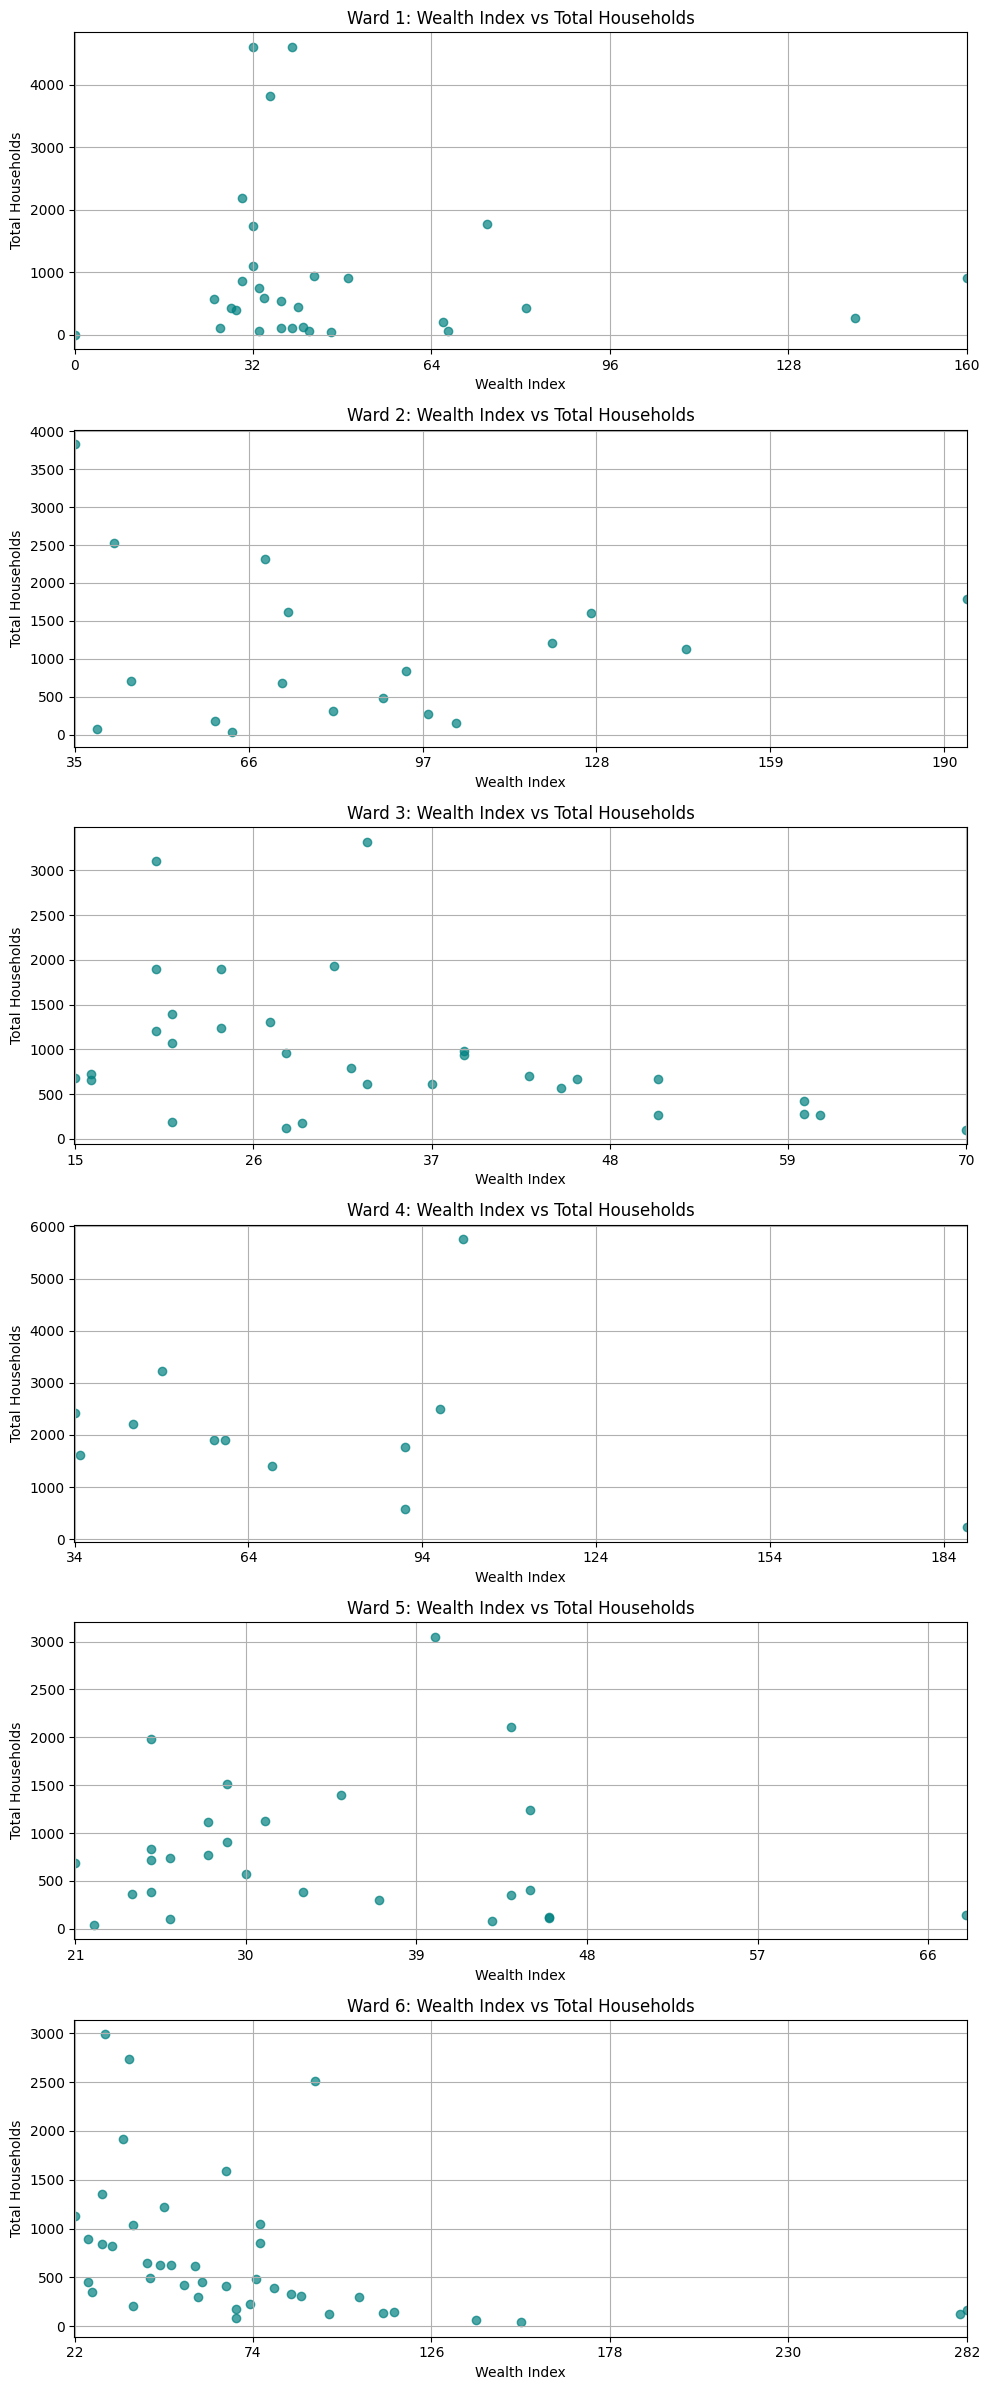

In [24]:
# Keep relevant columns for analysis
income_train = income_train[['WARD', 'NAME', 'TOTHH_CY', 'WLTHINDXCY']].copy()

# Rename columns for consistency
income_train.rename(columns={
    'WARD': 'Ward',  # Match the crime data's column name
    'NAME': 'Neighborhood',
    'TOTHH_CY': 'TotalHouseholds',
    'WLTHINDXCY': 'WealthIndex'
}, inplace=True)

# Handle missing values
income_train['TotalHouseholds'] = income_train['TotalHouseholds'].fillna(0).astype(int)
income_train['WealthIndex'] = income_train['WealthIndex'].fillna(income_train['WealthIndex'].median())

# Sort the data by Ward in ascending order to ensure numerical order
income_train = income_train.sort_values(by='Ward')

# Display the processed DataFrame
household_counts = income_train.groupby('Ward')['TotalHouseholds'].sum().reset_index()

# Plot number of households per ward
plt.figure(figsize=(10, 6))
sns.barplot(x='Ward', y='TotalHouseholds', data=household_counts, palette='Blues_d')
plt.title('Total Households per Ward')
plt.xlabel('Ward')
plt.ylabel('Total Households')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Scatterplots: WealthIndex vs TotalHouseholds for each ward
wards = income_train['Ward'].unique()
num_wards = len(wards)

# Sort wards in numerical order
wards = sorted(wards)  # Ensure wards are in ascending order

fig, axes = plt.subplots(num_wards, 1, figsize=(10, num_wards * 4), sharex=False)

for i, ward in enumerate(wards):
    ward_data = income_train[income_train['Ward'] == ward]
    axes[i].scatter(
        ward_data['WealthIndex'],  # Now WealthIndex is on the x-axis
        ward_data['TotalHouseholds'],  # TotalHouseholds is on the y-axis
        alpha=0.7,
        label=f'Ward {ward}',
        color='teal'
    )
    axes[i].set_title(f'Ward {ward}: Wealth Index vs Total Households')
    axes[i].set_xlabel('Wealth Index')  # Label for the x-axis
    axes[i].set_ylabel('Total Households')  # Label for the y-axis
    axes[i].grid(True)

    # Set the x-axis range based on the data for each ward, with custom padding
    min_wealth_index = ward_data['WealthIndex'].min()
    max_wealth_index = ward_data['WealthIndex'].max()
    axes[i].set_xlim(min_wealth_index - 0.05, max_wealth_index + 0.05)  # Add some padding

    # Customize x-ticks based on the data range
    axes[i].set_xticks(range(int(min_wealth_index), int(max_wealth_index) + 1, (int(max_wealth_index) - int(min_wealth_index)) // 5 or 1))

# Adjust layout for readability
plt.tight_layout()
plt.show()


# Data Processing and Visualizations (#3)

This script analyzes the distribution of different crime types across wards by merging crime and income data, grouping and transforming it for visualization.

## Data Preprocessing  
### Step 1: **Merging Datasets**  
- **Objective:**  
  Combine crime data and income data to enrich the dataset with neighborhood information.  
- **Details:**  
  - Performed an inner join on the `Ward` column.  
  - Retained only rows where the `Ward` exists in both datasets.  
  - Extracted `Neighborhood` information from the income dataset for contextual details.  

### Step 2: **Aggregating Crime Data**  
- **Objective:**  
  Group and count crime occurrences for each combination of `Ward` and `UCRDescription` (crime type).  
- **Details:**  
  - Used the `groupby` function to aggregate data.  
  - Reset the index and created a new column, `CrimeCount`, to store the total counts for each group.

---

## Data Transformation for Visualization  
### Step 1: **Pivoting the Data**  
- **Objective:**  
  Transform the grouped data into a wide format for easier visualization.  
- **Details:**  
  - Rows represent `Ward`, columns represent unique crime types (`UCRDescription`), and values are crime counts.  
  - Missing values (Wards with no occurrences for certain crime types) are filled with `0`.  

### Step 2: **Resetting the Index**  
- **Purpose:**  
  Ensure `Ward` is a regular column for easy plotting, rather than an index.  

---

## Graph: **Count of Each Crime Type by Ward**  
- **Objective:**  
  To visually compare the distribution of crime types across wards.  
- **Details:**  
  - A grouped bar chart is used where:  
    - X-axis: Wards.  
    - Y-axis: Crime Count.  
    - Different colors represent various crime types (columns).  
  - A distinct colormap (`tab20`) ensures clarity among categories.  
  - Transparency (`alpha=0.7`) enhances readability when bars overlap.  

- **Annotations and Legends:**  
  - Title: Clearly states the purpose of the visualization.  
  - Labels:  
    - X-axis: `Ward`  
    - Y-axis: `Crime Count`  
  - Legend: Positioned outside the plot for better layout, with a title "Crime Type (UCRDescription)".  
  - X-ticks: Rotated by 45° to avoid overlap.


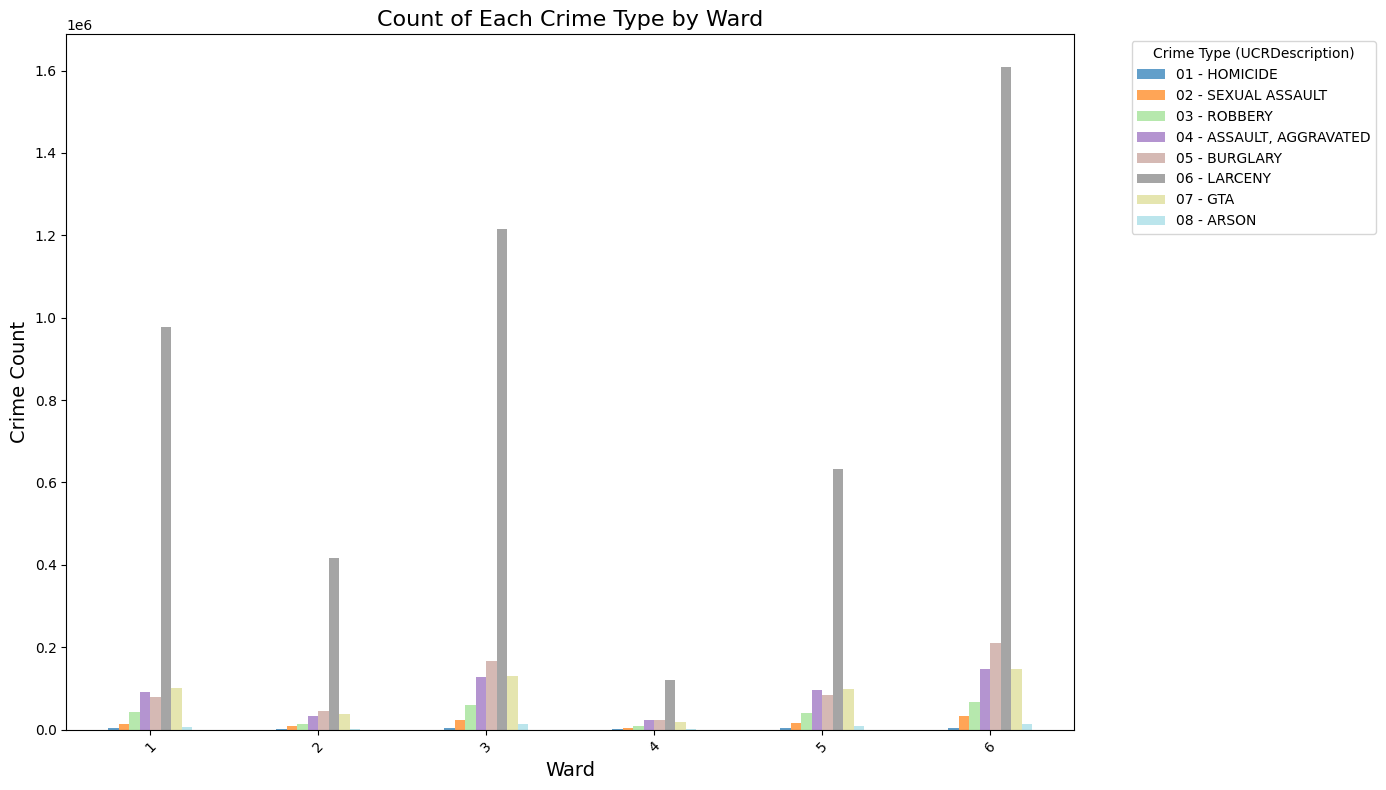

In [25]:
# Merge crime data with income data on the 'Ward' column
merged_data = crimes_train.merge(income_train[['Ward', 'Neighborhood']], on='Ward', how='inner')

# Group by Ward and UCRDescription to count occurrences of each crime type
crime_by_ward = merged_data.groupby(['Ward', 'UCRDescription']).size().reset_index(name='CrimeCount')

# Pivot the data for easier plotting
crime_pivot = crime_by_ward.pivot(index='Ward', columns='UCRDescription', values='CrimeCount').fillna(0)

# Reset the index for plotting
crime_pivot = crime_pivot.reset_index()

# Plot grouped bar chart
crime_pivot.set_index('Ward').plot(kind='bar', figsize=(14, 8), stacked=False, alpha=0.7, colormap='tab20')

# Add labels and title
plt.title('Count of Each Crime Type by Ward', fontsize=16)
plt.xlabel('Ward', fontsize=14)
plt.ylabel('Crime Count', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='Crime Type (UCRDescription)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Data Processing and Visualizations (#4)

This script explores the relationship between average Wealth Index and total crime across different wards by performing the following steps:


1. **Calculate Average Wealth Index per Ward**  
   - Aggregates the average Wealth Index for each ward from the neighborhood income dataset.  
   - Provides insights into the economic status of different wards.  

2. **Aggregate Total Crime per Ward**  
   - Calculates the total number of reported crimes for each ward from the crime dataset.  
   - Summarizes crime levels across the city.  

3. **Merge Datasets**  
   - Combines the average Wealth Index and total crime data by merging the two datasets on the 'Ward' column.  
   - Creates a unified dataset for analyzing the relationship between wealth and crime.  

4. **Scatter Plot and Linear Regression**  
   - Generates a scatter plot to visualize the relationship between the Average Wealth Index (x-axis) and Total Crime (y-axis) for each ward.  
   - Uses color-coding to differentiate wards and includes transparency to improve plot readability.  

5. **Linear Regression Model**  
   - Fits a linear regression model to the data to determine the trend between Wealth Index and crime levels.  
   - Overlays the regression line on the scatter plot to highlight the direction and strength of the relationship.  


This visualization provides a clear view of how economic factors, represented by the Wealth Index, correlate with crime levels, aiding in policy-making and targeted interventions.


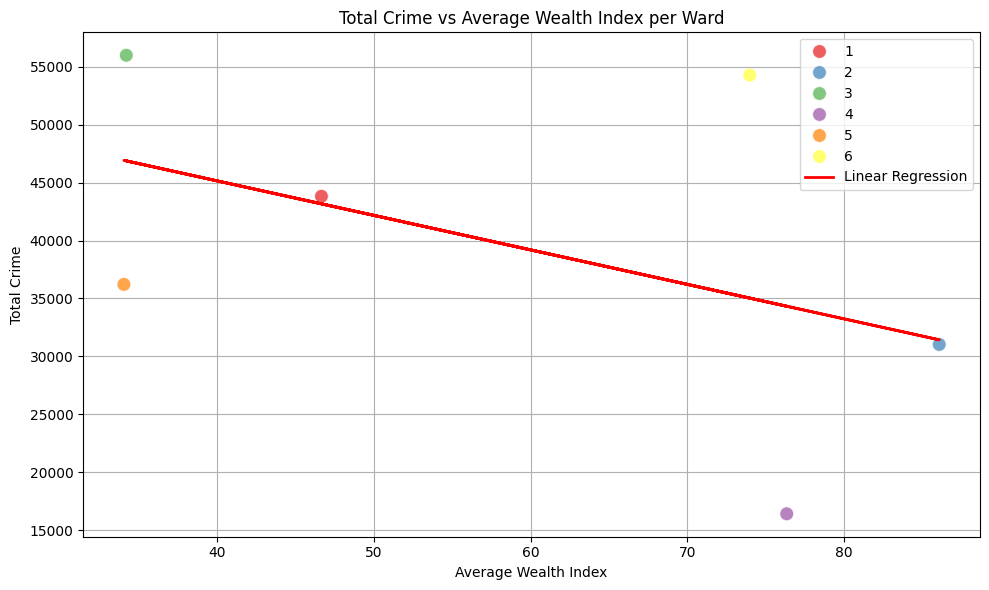

In [26]:
# Step 1: Calculate average Wealth Index per ward
avg_wealth_per_ward = income_train.groupby('Ward')['WealthIndex'].mean().reset_index(name='AvgWealthIndex')

# Step 2: Aggregate total crime per ward
total_crime_per_ward = crimes_train.groupby('Ward').size().reset_index(name='TotalCrime')

# Step 3: Merge the data on 'Ward' to combine avg wealth and total crime
merged_data = pd.merge(avg_wealth_per_ward, total_crime_per_ward, on='Ward')

# Step 4: Create scatter plot and linear regression

plt.figure(figsize=(10, 6))

# Scatter plot: Avg Wealth Index vs Total Crime
sns.scatterplot(x='AvgWealthIndex', y='TotalCrime', data=merged_data, hue='Ward', palette='Set1', s=100, alpha=0.7)

# Step 5: Linear regression
X = merged_data[['AvgWealthIndex']].values  # Features: Avg Wealth Index
y = merged_data['TotalCrime'].values        # Target: Total Crime
model_1 = lm.LinearRegression()
model_1.fit(X, y)
predictions = model_1.predict(X)

# Plot regression line
plt.plot(merged_data['AvgWealthIndex'], predictions, color='red', label='Linear Regression', linewidth=2)

# Step 6: Display regression statistics
plt.title('Total Crime vs Average Wealth Index per Ward')
plt.xlabel('Average Wealth Index')
plt.ylabel('Total Crime')
plt.legend()
plt.grid(True)

# Show plot
plt.tight_layout()
plt.show()


# Data Processsing and Visualization (#5)
This script creates a comprehensive analysis of the relationship between Wealth Index and crime counts at the neighborhood level.

## Graph 1: **Wealth Index vs Crime Count**  
- **Objective:**  
  To explore the direct relationship between the Wealth Index and Crime Count per neighborhood.  
- **Details:**  
  - A scatter plot is used, with Wealth Index on the x-axis and Crime Count on the y-axis.  
  - Each data point represents a neighborhood.  
  - Transparency is applied to improve readability in densely plotted areas.  
  - Helps to identify trends, clusters, or outliers in the data.

## Graph 2: **Segmented Wealth Index and Crime Count Analysis**  
### Step 1: **Neighborhood Segmentation by Wealth Index**  
- **Process:**  
  - The neighborhoods are sorted based on their Wealth Index.  
  - The data is divided into chunks of 50 neighborhoods each.  
  - For each chunk, the following averages are calculated:  
    - **Wealth Index**  
    - **Crime Count**  

### Step 2: **Bar Plot: Average Wealth Index vs Average Crime**  
- **Objective:**  
  To provide a simplified view of how crime counts vary with wealth levels across segments of neighborhoods.  
- **Details:**  
  - A bar plot is generated with the average Wealth Index (x-axis) and average Crime Count (y-axis).  
  - Each bar represents a 50-neighborhood segment.  
  - X-tick labels are rotated for better readability.  

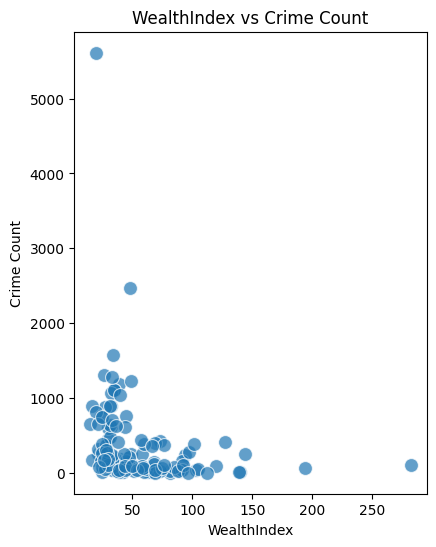

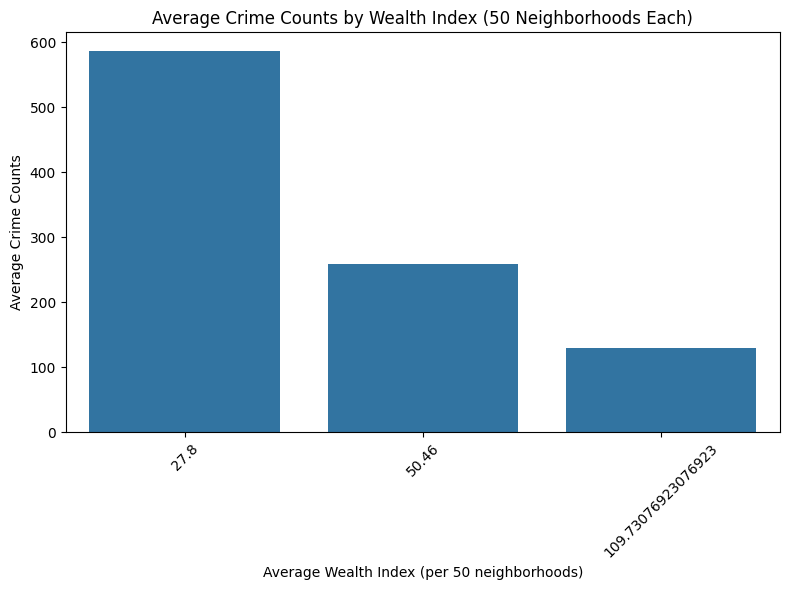

In [32]:
"""
 This assembles the data frames necessary to complete the visualizations below as well as model1 in the textcode below
"""

# Grab all arrests and the neighborhood in which they occurred
uncleaned_data = arrests_df[['NeighborhoodAssociation']].copy()

# Filter out unspecified values
uncleaned_data = uncleaned_data.dropna()

# Filter out neighborhoods that are not found and or listed under Neighborhood_income.csv
filtered_data_1 = uncleaned_data[uncleaned_data['NeighborhoodAssociation'].isin(income_train['Neighborhood'])]

# Count the amount of crimes per neighborhood
arrests_per_neighborhood = filtered_data_1['NeighborhoodAssociation'].value_counts().reset_index()
arrests_per_neighborhood.columns = ['Neighborhood', 'Crime_Count']

# Merge income_by_neighborhood and arrests_by_neighborhood into one dataframe
neighborhood_df = income_train.merge(arrests_per_neighborhood, on='Neighborhood')

# Plot size
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='WealthIndex', y='Crime_Count', data=neighborhood_df, s=100, alpha=0.7)
plt.title('WealthIndex vs Crime Count')
plt.xlabel('WealthIndex')
plt.ylabel('Crime Count')

# Sort by WealthIndex
data = neighborhood_df.sort_values(by='WealthIndex')
wealth_indexes = data['WealthIndex'].values
arrest_counts = data['Crime_Count'].values

chunk_size = 50
average_wealth = []
average_crime = []

for start in range(0, len(wealth_indexes), chunk_size):
    w_slice = wealth_indexes[start:start+chunk_size]
    c_slice = arrest_counts[start:start+chunk_size]

    avg_w = np.mean(w_slice)
    avg_c = np.mean(c_slice)

    average_wealth.append(avg_w)
    average_crime.append(avg_c)

# Create binned_df for wealth and crime
binned_df = pd.DataFrame({
    'Average_WealthIndex': average_wealth,
    'Average_Crime': average_crime,
})

# Plot the crime vs wealth index
plt.figure(figsize=(8, 6))
sns.barplot(x='Average_WealthIndex', y='Average_Crime', data=binned_df)
plt.title('Average Crime Counts by Wealth Index (50 Neighborhoods Each)')
plt.xlabel('Average Wealth Index (per 50 neighborhoods)')
plt.ylabel('Average Crime Counts')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Model #1

This script analyzes the relationship between neighborhoods and crime
in Tucson by cleaning and merging arrest and income data, engineering features, training a
linear regression model, and evaluating its performance with R-squared, MSE, and a visualization of
predicted vs. actual crime counts.

### Step 1: Feature and Output Selection  
**Process:**  
- Key features (`WealthIndex` and `TotalHouseholds`and the target variable (`Crime_Count`)) are defined.  
- These features represent socioeconomic data for neigborhoods that are relevant to crime prediction.  

---

### Step 2: Data Preparation  
**Objective:**  
To clean and prepare the data for effective model training.  

**Details:**  
- Extract feature set (`X`) and target variable (`y`) from the `neighborhood_df` DataFrame.  
- Remove an outlier case (index 81) from both `X` and `y` to avoid skewing the model.  See the report for a more in depth explanation for the removal of index 81.

---

### Step 3: Model Training  
**Objective:**  
To build and train a linear regression model to predict crime counts.  

**Details:**  
- Instantiate a linear regression model using `lm.LinearRegression()`.  
- Fit the model on the training data (`X_train`, `y_train`) with `model.fit()`.  

---

### Step 4: Model Testing and Prediction  
**Objective:**  
To assess the model's ability to predict crime counts on unseen data.  

**Details:**  
- Use `model.predict()` to predict crime counts (`y_pred`) for the test data (`X_test`).  

---

### Step 5: Feature Interpretation  
**Objective:**  
To understand the relationship between features and crime counts.  

**Details:**  
- Retrieve model coefficients (`model.coef_`) and map them to corresponding features.  
- Print each feature alongside its coefficient to analyze its contribution to crime prediction.  

---

### Step 6: Model Performance Evaluation  
**Objective:**  
To measure the model’s prediction accuracy.  

**Details:**  
- Calculate the R-squared value (`model.score()`) to assess the variance explained by the model.  
- Compute the MSE for the model’s predictions and print the results.  

---

### Step 7: Visualization: Actual vs Predicted Crime Counts  
**Objective:**  
To visually compare the model's predictions with actual values.  

**Details:**  
- Generate a scatter plot of actual crime counts (`y_test`) vs predicted counts (`y_pred`).  
- Include a reference line to indicate perfect predictions.  
- Label axes and add a title for clarity.  



Below are the coefficients for the model
Feature: WealthIndex, -2.4382
Feature: TotalHouseholds, 0.2142

Assessments of Performance
Baseline MSE: 1167674.1475999998
Mean Squared Error: 933382.2083854728
R-squared value: 0.19974532459306293


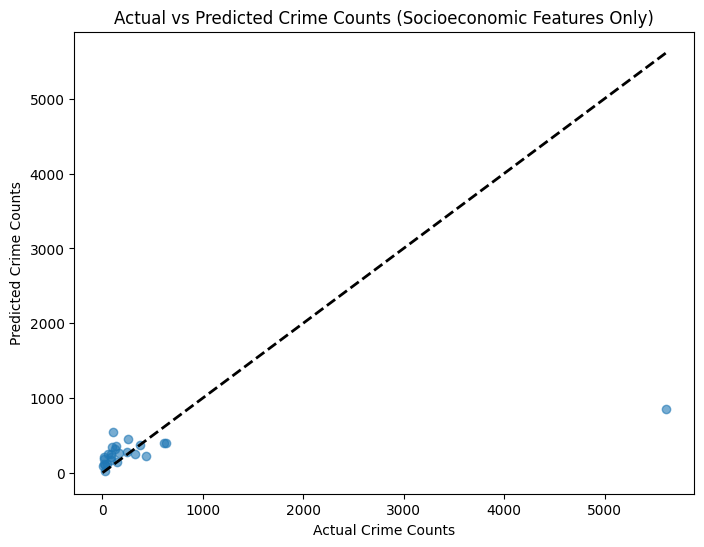

In [33]:
# Grab the model's features
features = ['WealthIndex', 'TotalHouseholds']
output = ['Crime_Count']

# Create our training data
X = neighborhood_df[features]
X = X.drop(81)  # outlier case

y = neighborhood_df[output]
y = y.drop(81)  # outlier case

# Break the training data into 80 / 20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train our model
model = lm.LinearRegression()
model.fit(X_train, y_train)

# Now test our model
y_pred = model.predict(X_test)

# Show the features and their relationship to crime count
print("Below are the coefficients for the model")
for feature, coef in zip(features, model.coef_[0]):
    print(f'Feature: {feature}, {round(coef, 4)}')
print("")

print("Assessments of Performance")
y_mean = y_train.mean()
baseline_preds = [y_mean] * len(y_test)
baseline_mse = metrics.mean_squared_error(y_test, baseline_preds)
print("Baseline MSE:", baseline_mse)

mse = metrics.mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

r2 = model.score(X_test, y_test)
print(f'R-squared value: {r2}')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Crime Counts')
plt.ylabel('Predicted Crime Counts')
plt.title('Actual vs Predicted Crime Counts (Socioeconomic Features Only)')

plt.show()

## Model 2

This script analyzes the relationship between neighborhoods and crime, we trained a logistic
model to classify neighborhoods based on their features such income mean and total house populations 
to determine whether the given neighborhood is a high crime rate or low crime rate neigborhood.


### Step 1: Crime Classification by Threshold  
Process:
- Median crime count is calculated and used as a threshold.  
- A binary feature, `High_Crime`, is created to classify neighborhoods:  
  - 1: High-Crime (above the median).  
  - 0: Low-Crime (below or equal to the median).  

---

### Step 2: Feature Selection and Data Splitting  
Process:
- Features: Wealth Index and Total Households.
- Target: `High_Crime` (binary classification).  
- Data split:  
  - Training (80%)
  - Testing (20%)
- Features are standardized using `StandardScaler`.  

---

### Step 3: Logistic Regression with Cross-Validation  
Process:
- A logistic regression model is trained with 5-fold cross-validation.  
- Regularization strength is tuned automatically.  

---

### Step 5: Model Evaluation  
Metrics:  
- Baseline Accuracy (predicting all as the majority class): e.g., 0.65.  
- Confusion Matrix:
- Classification Report: Precision, Recall, F1-Score.  

---

### Step 6: ROC Curve  
Details:  
- Plots True Positive Rate (TPR) vs. False Positive Rate (FPR).  
- Area Under Curve (AUC): e.g., 0.87, indicating good model performance.  

---

### Visualizations  
- Feature Coefficients: Show the relationship between predictors and crime classification.  
- ROC Curve: Highlights model performance compared to a random baseline.  

Below are the coefficients for the model
WealthIndex -0.024616951626251143
TotalHouseholds 0.0027544431494458633

Assessments of Performance
Baseline Accuracy: 0.5
[[11  2]
 [ 3 10]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.81        13
           1       0.83      0.77      0.80        13

    accuracy                           0.81        26
   macro avg       0.81      0.81      0.81        26
weighted avg       0.81      0.81      0.81        26



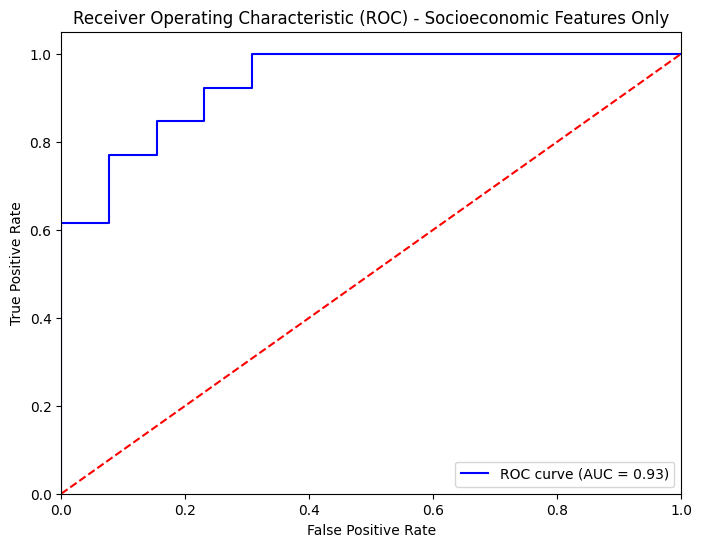

In [ ]:
# Calculate the median crime count from the data
threshold = neighborhood_df['Crime_Count'].median()

# Add a new feature to the df, which is the threshold which classifies neighborhoods as high or low crime
neighborhood_df['High_Crime'] = (neighborhood_df['Crime_Count'] > threshold).astype(int)

# Grab the model's features
features = ['WealthIndex', 'TotalHouseholds']

output = 'High_Crime'

# Create our training data
X = neighborhood_df[features]
y = neighborhood_df[output]

# Break the training data into 80 / 20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()

# Build and train our model
model = lm.LogisticRegressionCV(cv=5, max_iter=10000, random_state=0, Cs=10)
model.fit(X_train, y_train)

# Now test our model
y_pred = model.predict(X_test)

print("Below are the coefficients for the model")
for feature, coef in zip(features, model.coef_[0]):
    print(feature, coef)
print("")

print("Assessments of Performance")
# Calculate the baseline
majority_class = y_train.value_counts().idxmax()
baseline_preds = [majority_class] * len(y_test)
baseline_accuracy = metrics.accuracy_score(y_test, baseline_preds)
print("Baseline Accuracy:", baseline_accuracy)

# Confusion matrix, precision, recall, F1-score
print(metrics.confusion_matrix(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

# Show the ROC Curve
y_scores = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_scores)
roc_auc = metrics.auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Socioeconomic Features Only')
plt.legend(loc="lower right")
plt.show()